In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal, eigh
from scipy.interpolate import interp1d
from scipy.integrate import quad
from pyscf import gto, scf
import seaborn as sns

This notebook was conceptualized, organized, and primarily prepared for the *Physics 2* Extra Credit

### This notebook uses the following references:
Mr. P Solver. (2022, May 30). Linear Combination of Atomic Orbitals (LCAO) in Python [Video]. YouTube. https://www.youtube.com/watch?v=YzuaiD2e5oI

PySCF Developers. (n.d.). PySCF User Guide. Retrieved April 26, 2026, from https://pyscf.org/user/index.html

# Linear Combination of Atomic Orbitals (LCAO) and Tight-Binding Models

## Introduction
This notebook explores the **Linear Combination of Atomic Orbitals (LCAO)** method, a fundamental technique in quantum chemistry and condensed matter physics. We use it to approximate the electronic structure of molecules and crystalline solids.

### Core Concept
The LCAO approach assumes that the wavefunction of an electron in a multi-well potential (like an array of atoms) can be represented as a linear combination of the wavefunctions of the individual, isolated wells.

$$\Psi(x) = \sum_{n, i} c_{n,i} \phi_i(x - x_n)$$

where $\phi_i$ is the $i$-th eigenstate of a single well centered at $x_n$.

**LINEAR COMBINATION OF ATOMIC ORBIRTALS (LCAO) Approximation**: This model **assumes** that molecular states are a linear combination of known atomic states. We'll use the notation

$$\ket{i}_j$$

where this represents the $i$th excited state of the $j$th well. The LCAO approximation says that any state can be represented as

$$\ket{\psi} = \sum_{j} \sum_i c_{ij}\ket{i}_j$$

where $c_ij$ are coefficients that make up the linear combination. Thus the $\ket{i}_j$ form a complete basis. Suppose we have 3 wells, each with two states (a ground and excited state). In vector notation, we can write any state as

$$\ket{\psi} = \begin{bmatrix}c_1\\ c_2\\ c_3\\ c_4\\ c_5 \\ c_6  \end{bmatrix} \begin{matrix} \to \ket{0}_0\\ \to \ket{1}_0\\ \to \ket{0}_1\\ \to \ket{1}_1\\ \to \ket{0}_2\\ \to \ket{1}_2\\ \end{matrix}$$

where the $c$'s are the component of each of the $\ket{i}_j$s of the basis:

$$\ket{\psi} = c_1\ket{0}_0 + c_2\ket{1}_0 + c_3\ket{0}_1 + c_4\ket{1}_1 + c_1\ket{0}_2 + c_1\ket{1}_2$$

The Hamiltonian $H = T+\sum_i V_i$ of the full well system can be written in the basis of these $\ket{i}_j$s where each element of the hamiltonian matrix is

$$\bra{i'}_{j'}H\ket{i}_j$$

once we have this matrix, we can solve for the eigenvalues and eigenvectors and we're done. We just need a way to get these elements. For this we use

$$H = H_j + \hat{V}_j$$

where $H_j = T+V_j$ is the Hamiltonian of a well $j$ and $\hat{V}_j=\sum_{m \neq j} V_{m}$ is the potential from all the adjacent wells. Letting $n=j-j'$ (the number of wells apart), the matrix elements are given by:

$$\begin{align*} \bra{i'}_{j'}H\ket{i}_{j} &= \bra{i'}_{j'}H_j + \hat{V}_j \ket{i}_{j} \\ &= \bra{i'}_{j'}E_i + \hat{V}_j \ket{i}_{j} \\ &= \int_{-\infty}^{\infty} \phi_{i'}^{*}(x \pm nb) \left[E_i+\hat{V}(x)\right]\phi_{i}(x) dx \end{align*}$$

We can now get all the matrix elements and solve for the eigenvalues of the Hamiltonian!

## Part 1: Solving the Single Well Problem

Before we can build a crystal or a molecule, we need our 'atomic' building blocks. We solve the Schrödinger equation for a single finite square well using the **Finite Difference Method**. By representing the Laplacian as a tridiagonal matrix, we convert the differential equation into an eigenvalue problem.

Here's a function that solves for the *bound* (energies less than zero) eigenstates of some finite square well.

In [2]:
def solve_single_well(x, V, V0):
    N = len(x)
    dx = np.diff(x)[0]
    main_diag = 2*np.ones(N)/dx**2 + V(x,V0)
    off_diag =  -np.ones(N-1)/dx**2
    Es, psis = eigh_tridiagonal(main_diag, off_diag, select='v', select_range=(-V0,0))
    psis = psis/np.sqrt((np.abs(psis)**2).sum(axis=0) * dx)
    return Es, psis.T

## Part 2: Calculating Interactions (Matrix Elements)

In the LCAO basis, the Hamiltonian matrix elements $H_{nm} = \langle \phi_n | H | \phi_m \rangle$ determine the physics.
- **Diagonal elements** $H_{nn}$ represent the energy levels of the isolated 'atoms'.
- **Off-diagonal elements** $H_{nm}$ (where $n \neq m$) represent the 'hopping' or 'coupling' between sites. This coupling is what causes discrete energy levels to split and form bands.

With these eigenstates/energies, we can compute the matrix elements $\bra{i'}_{j'}H\ket{i}_{j} = \int_{-\infty}^{\infty} \phi_{i'}^{*}(x \pm nb) \left[E_i+\hat{V}(x)\right]\phi_{i}(x) dx $ of the Hamiltonian and solve our system!

## Examples to Consider

1. Finite Square Well (single bound state)
* $V_0 = 1$eV
* Well Width $2a=0.35$nm
* Well spacing $b = 3 \cdot 2a$

2. Finite Square Well (two bound states)
* $V_0 = 5$eV
* Well Width $2a=0.35$nm
* Well spacing $b = 3 \cdot 2a$

3. Gaussian Well
* $V = V_0 e^{-(3x/a)^2}$ where $V_0/(\frac{\hbar^2}{2ma^2}) = 36$
* Well spacing $b = 2 \cdot 2a$



Example 1:

In [3]:
'''Dimensionfull parameters'''
V0 = 1 #eV
hbar = 6.582112e-16 #eV s
m = 0.510999e6 / (3e8)**2 #eV s^2 / m^2
a = 0.35e-9 / 2 # m
f = hbar**2 / (2*m*a**2)
'''Dimensionless parameters'''
V0 = V0 / f
b = 3 * 2

Example 2:

In [4]:
'''Dimensionfull parameters'''
V0 = 5 #eV
hbar = 6.582112e-16 #eV s
m = 0.510999e6 / (3e8)**2 #eV s^2 / m^2
a = 0.35e-9 / 2 # m
f = hbar**2 / (2*m*a**2)
'''Dimensionless parameters'''
V0 = V0 / f
b = 3 * 2

Example 3:

In [5]:
'''Dimensionless parameters'''
V0 = 36
b = 2 * 2
f = 1 # correction factor is 1 because we'll just look at dimensionless energy eigenvalues

### Defining the System Geometry
In these code blocks, we define the physical properties of our wells. We use both dimensionful units (eV, nm) for physical intuition and dimensionless units for computational efficiency. The parameter $f$ serves as a conversion factor based on the well width and mass of the particle, allowing us to relate the numerical eigenvalues back to real-world energy scales.

### Potential Construction
We define the potential $V(x)$ based on the chosen example parameters. This potential represents the environment the electron 'feels' within a single unit cell or the entire system.

In [6]:
example = 3
N = 100000
x = np.linspace(-15,15,N)
if example==1 or example==2:
    def V(x, V0):
        return -V0*np.array((x>=-1)*(x<=1), dtype=float)
elif example==3:
    def V(x,V0):
        return -V0*np.exp(-(3*x)**2)

Plot the potential:

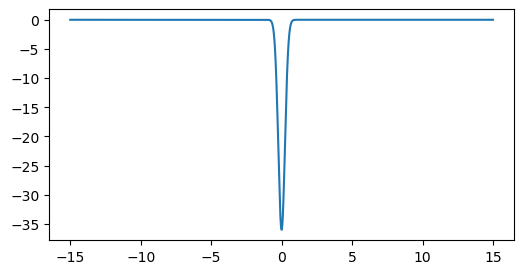

In [7]:
plt.figure(figsize=(6,3))
plt.plot(x, V(x,V0))
plt.show()

**Visualization: Potential Well**: The graph above shows the shape of the potential well. The 'well' creates a region where the electron is energetically confined, mirroring the electrostatic pull of an atomic nucleus.

### Basis States Visualization
We solve for the bound states of our single well. These will serve as our basis functions for the many-well system.

In [8]:
Es, psis = solve_single_well(x, V, V0)

Look at the energies

### Extracting Energy Eigenvalues
After solving the single-well problem, we extract the eigenvalues. These represent the quantized energy levels an electron can occupy within a single, isolated atom. In the LCAO method, these values will populate the main diagonal of our final Hamiltonian matrix.

In [9]:
f*Es

array([-21.37895221,  -1.35778458])

Plot all the wavefunctions

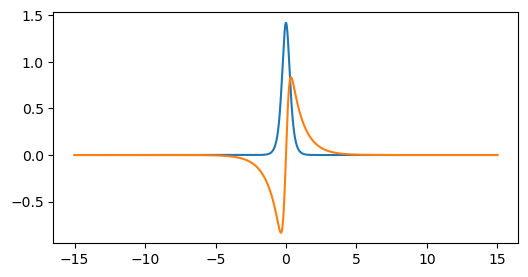

In [10]:
plt.figure(figsize=(6,3))
[plt.plot(x, psi) for psi in psis]
plt.show()

**Visualization: Atomic Orbitals**: These curves represent the spatial probability distribution of the electron in the single well. Note the nodes (crossings of zero) in the higher energy states.

### The Perturbing Potential
When an electron is near one well, it also feels the influence of all other wells. We define $\hat{V}(x)$ as the total potential minus the potential of the 'local' well. This term drives the interaction between sites.

In order to solve our integral, lets create a function that can compute the wavefunctions at any point $x$

In [11]:
psis_f = [interp1d(x, psi, bounds_error=False, fill_value=(0,0)) for psi in psis]

Define $\hat{V}(x)$: the potential from all the wells, **except** the one centered at $x=0$.

In [12]:
def Vp_f(x, b, V0):
    return V((x+b/2)%b-b/2,V0) - V(x,V0)

Plot the ground state wavefunctions from consecutive wells, along with $\hat{V}(x)$

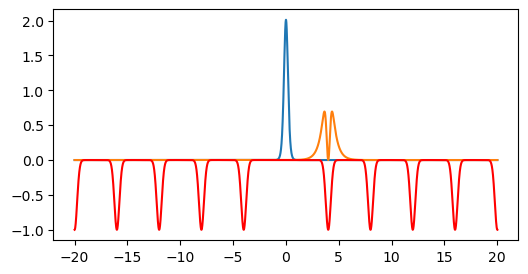

In [13]:
x_large = np.linspace(-20,20,10000)
plt.figure(figsize=(6,3))
plt.plot(x_large, psis_f[0](x_large)**2)
plt.plot(x_large, psis_f[1](x_large - b)**2)
plt.plot(x_large, Vp_f(x_large,b,V0)/V0, color='red')
plt.show()

### Numerical Integration of Couplings
We use `scipy.integrate.quad` to compute the overlap integrals. This tells us the strength of the interaction between a state in one well and a state in a neighboring well.

Function that computes $\int_{-\infty}^{\infty} \phi_i^{*}(x) \left[E_i+\hat{V}(x)\right]\phi_{i'}(x \pm nb) dx$

In [14]:
def compute_integral(psis_f, Es, i1, i2, b, V0, n):
    return quad(lambda x: psis_f[i1](x)*psis_f[i2](x-n*b)*(Es[i1]+Vp_f(x, b, V0)),
                -20, 20, points=[n*b for n in range(-6,6)], limit=1000)[0]

### Verifying the Hopping Integral
The following cell calculates a single coupling term between two neighboring wells. This value represents the 'hopping' probability—the likelihood of an electron tunneling from one well to the next. In tight-binding models, this is often denoted as the parameter $t$ or $eta$.

In [15]:
f*compute_integral(psis_f,Es,0,0, b=6, V0=V0, n=1)

-1.5380149844648436e-09

## Part 3: Building the Global Hamiltonian

We now tile our 'atoms' to create a 1D lattice (a chain of wells). The resulting Hamiltonian is a large matrix where each block corresponds to a well and off-diagonal blocks represent the coupling between neighbors.

## Fill the Hamiltonian matrix $H$

**Part 1**: Create Matrix

In [16]:
N_wells = 20
N_states = len(Es)
H = np.zeros((N_wells*N_states,N_wells*N_states))

**Part 2**: Fill Off diagonals

In [17]:
psis_tot = N_wells*psis_f
Es_tot = N_wells*list(Es)
for i1 in range(H.shape[0]):
    for i2 in range(i1, H.shape[0]):
        well1_idx = i1//N_states
        well2_idx = i2//N_states
        H[i1,i2] = compute_integral(psis_tot,Es_tot,i1,i2,b=b,V0=V0,n=well2_idx-well1_idx)
H += H.T

**Part 3**: Fill Main diagonal

In [18]:
main_diag = np.array(list(Es)*N_wells)
H[np.diag_indices(H.shape[0])] = main_diag

Show a visual representation of the Hamiltonian

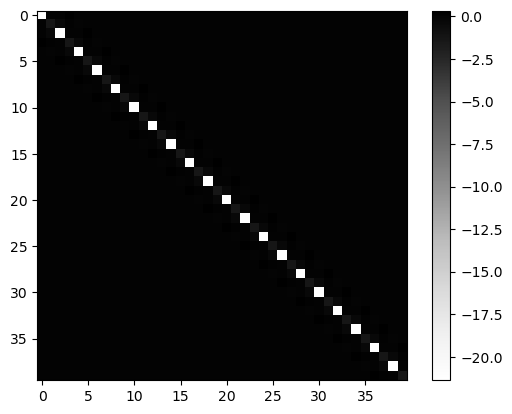

In [19]:
plt.imshow(H, cmap='Greys')
plt.colorbar()
plt.show()

**Visualization: Hamiltonian Structure**: This heat map shows how the energy is distributed. The dark diagonal line represents the energy levels of isolated atoms, while the faint off-diagonal lines show the coupling (hopping) between neighbors.

## Part 4: Energy Bands and Eigenstates

By diagonalizing the full Hamiltonian, we find the allowed energy levels of the entire system. In a periodic system with many wells, we expect to see the formation of **energy bands**.

Solve for the allowed energies and states of an electron in this system:

### Solving the Global System
By diagonalizing the full $N 	imes N$ Hamiltonian, we find the collective states of the entire chain of atoms. This step accounts for the interaction of every state in every well, leading to the splitting of single-atom energy levels into a distribution of states.

In [20]:
eigenenergies, eigenvectors = np.linalg.eigh(H)

### Visualization: The Energy Spectrum
The vertical lines in the following plot show the allowed energy levels for the combined system. Notice how they form clusters; these are the precursors to **energy bands**. The width of these clusters is directly determined by the strength of the hopping integrals calculated earlier.

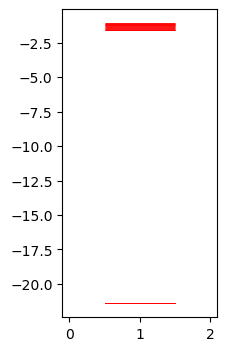

In [21]:
plt.figure(figsize=(2,4))
plt.eventplot(f*eigenenergies, orientation='vertical', colors='r', linewidths=0.5)
plt.show()

**Visualization: Energy Band Formation**: This plot shows the discrete energy levels of the entire system. As we add more wells, these levels cluster into 'bands,' demonstrating how metals and semiconductors gain their electronic properties.

In [22]:
eigenenergies

array([-21.40124597, -21.40124536, -21.39977253, -21.39977022,
       -21.39746258, -21.39745779, -21.39452121, -21.39451363,
       -21.39120959, -21.39119943, -21.38782184, -21.38780979,
       -21.38465895, -21.38464591, -21.38200216, -21.38198881,
       -21.38008837, -21.38007387, -21.37909388, -21.37906423,
        -1.59169285,  -1.58355975,  -1.57019826,  -1.55189484,
        -1.52904249,  -1.50213293,  -1.47174689,  -1.43854263,
        -1.40324295,  -1.36662076,  -1.32948347,  -1.2926563 ,
        -1.25696471,  -1.22321615,  -1.19218148,  -1.16457641,
        -1.1410434 ,  -1.12213481,  -1.10829764,  -1.09986093])

**For example 1**: Theoretically, the allowed energies are

In [23]:
idx = eigenenergies>-1

# Self-Consistent Field (Hartree-Fock) Method

While the previous sections used a 'single-particle' tight-binding model, real chemical systems involve electron-electron repulsions. The **Hartree-Fock (HF)** method solves this using an iterative **Self-Consistent Field (SCF)** approach.

Here, we simulate a simple 2-orbital system (like $H_2$) where we account for:
1. **Core Hamiltonian**: Kinetic energy and electron-nuclear attraction.
2. **Electron-Electron Repulsion**: The Coulomb and Exchange integrals ($g$ tensor).
3. **Overlap Matrix**: Non-orthogonal basis considerations.

## COMPUTATION USING HARDTREE FOCK

### The Hartree-Fock Procedure
Moving beyond single-particle models, we implement a Self-Consistent Field (SCF) method. We define our convergence criteria (how small the change in energy must be to stop) and our iteration limits.

In [24]:
BASIS_SIZE = 2  # Two 1s orbitals
MAX_ITER = 50   # Maximum SCF iterations
CONV_CRIT = 1e-7 # Convergence threshold

In [25]:
# Make Matrix
S = np.array([[1.0, 0.6593],
              [0.6593, 1.0]])

H_core = np.array([[-1.1204, -0.9584],
                   [-0.9584, -1.1204]])

g = np.zeros((2, 2, 2, 2))
g[0,0,0,0] = 0.7746; g[1,1,1,1] = 0.7746
g[0,0,1,1] = 0.5697; g[1,1,0,0] = 0.5697
g[0,1,0,1] = 0.2227; g[1,0,1,0] = 0.2227
g[0,1,1,1] = 0.4446; g[1,1,0,1] = 0.4446

### Symmetric Orthogonalization
Because atomic orbitals are not naturally orthogonal, the overlap matrix $S$ is not identity. We use the transformation matrix $X = S^{-1/2}$ to transform our basis into an orthogonal set, allowing us to solve the standard eigenvalue problem $Fc = \epsilon Sc$ as $F'c' = \epsilon c'$.

In [26]:
evals, evecs = np.linalg.eigh(S)
X = evecs @ np.diag(evals**-0.5) @ evecs.T

print("Orthogonalization matrix X created successfully.")

Orthogonalization matrix X created successfully.


### The SCF Loop
This loop is the heart of the Hartree-Fock method. In each step:
1. We construct the **Fock Matrix** $F$, which includes the core Hamiltonian and the electron-electron repulsion (Coulomb and Exchange terms).
2. We solve the eigenvalue problem to find new Molecular Orbital (MO) coefficients.
3. We calculate the new electronic energy and update the density matrix $P$.
4. We check if the energy has converged.

In [27]:
P = np.zeros((BASIS_SIZE, BASIS_SIZE))
E_old = 0.0

print(f"{'Iteration':<12} | {'Electronic Energy (Ha)':<22} | {'Delta E':<15}")
print("-" * 55)

for i in range(MAX_ITER):
    # Build the Fock Matrix (F = H + G)
    G = np.zeros((BASIS_SIZE, BASIS_SIZE))
    for mu in range(BASIS_SIZE):
        for nu in range(BASIS_SIZE):
            for la in range(BASIS_SIZE):
                for si in range(BASIS_SIZE):
                    # Coulomb and Exchange interactions
                    G[mu, nu] += P[la, si] * (g[mu, nu, la, si] - 0.5 * g[mu, la, nu, si])

    F = H_core + G

    # Transform Fock to orthogonal basis: F' = X.T @ F @ X
    F_prime = X.T @ F @ X

    # Diagonalize F' to get energies and coefficients
    epsilon, C_prime = np.linalg.eigh(F_prime)

    # Transform coefficients back to original basis: C = X @ C'
    C = X @ C_prime

    # Update Density Matrix P (for 2 electrons in the lowest orbital)
    P_new = np.zeros((BASIS_SIZE, BASIS_SIZE))
    for mu in range(BASIS_SIZE):
        for nu in range(BASIS_SIZE):
            P_new[mu, nu] = 2 * C[mu, 0] * C[nu, 0]

    # Calculate Total Electronic Energy
    E_elec = 0.5 * np.sum(P_new * (H_core + F))
    delta_e = np.abs(E_elec - E_old)

    print(f"{i:<12} | {E_elec:<22.8f} | {delta_e:<15.2e}")

    if delta_e < CONV_CRIT:
        print("\nConvergence achieved.")
        break

    P = P_new
    E_old = E_elec

Iteration    | Electronic Energy (Ha) | Delta E        
-------------------------------------------------------
0            | -2.50563491            | 2.51e+00       
1            | -2.15002632            | 3.56e-01       
2            | -2.14769680            | 2.33e-03       
3            | -2.14703223            | 6.65e-04       
4            | -2.14698371            | 4.85e-05       
5            | -2.14698051            | 3.20e-06       
6            | -2.14698030            | 2.09e-07       
7            | -2.14698029            | 1.37e-08       

Convergence achieved.


Total Molecular Energy: -1.43328 Hartree

Molecular Orbital Coefficients (Columns are MOs):
[[-0.6333248  -1.16952912]
 [-0.46179449  1.24725479]]


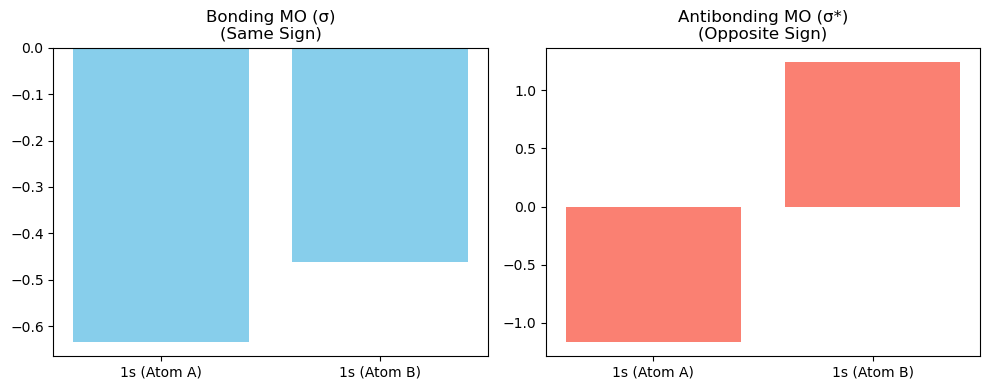

In [28]:
E_total = E_elec + 0.7137

print(f"Total Molecular Energy: {E_total:.5f} Hartree")
print("\nMolecular Orbital Coefficients (Columns are MOs):")
print(C)

# Simple visual representation of the MOs
labels = ['1s (Atom A)', '1s (Atom B)']
x = np.arange(len(labels))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].bar(x, C[:, 0], color='skyblue')
ax[0].set_title("Bonding MO (σ)\n(Same Sign)")
ax[0].set_xticks(x, labels)

ax[1].bar(x, C[:, 1], color='salmon')
ax[1].set_title("Antibonding MO (σ*)\n(Opposite Sign)")
ax[1].set_xticks(x, labels)

plt.tight_layout()
plt.show()

### Benchmarking with PySCF
To ensure our manual implementation is accurate, we use PySCF to model a Hydrogen molecule ($H_2$). Here we use a standard '6-31G' basis set, which uses a combination of Gaussian functions to represent the atomic orbitals more accurately than our simple square wells.

In [29]:
mol = gto.M(
    atom='H 0 0 0; H 0 0 1',  # Hydrogen molecule, atoms 1 angstrom apart
    basis='6-31g'                # The LCAO basis set
)

# 2. Create the SCF object (Mean-field)
mf = scf.RHF(mol)
mf.kernel()

converged SCF energy = -1.09480796286051


np.float64(-1.094807962860512)

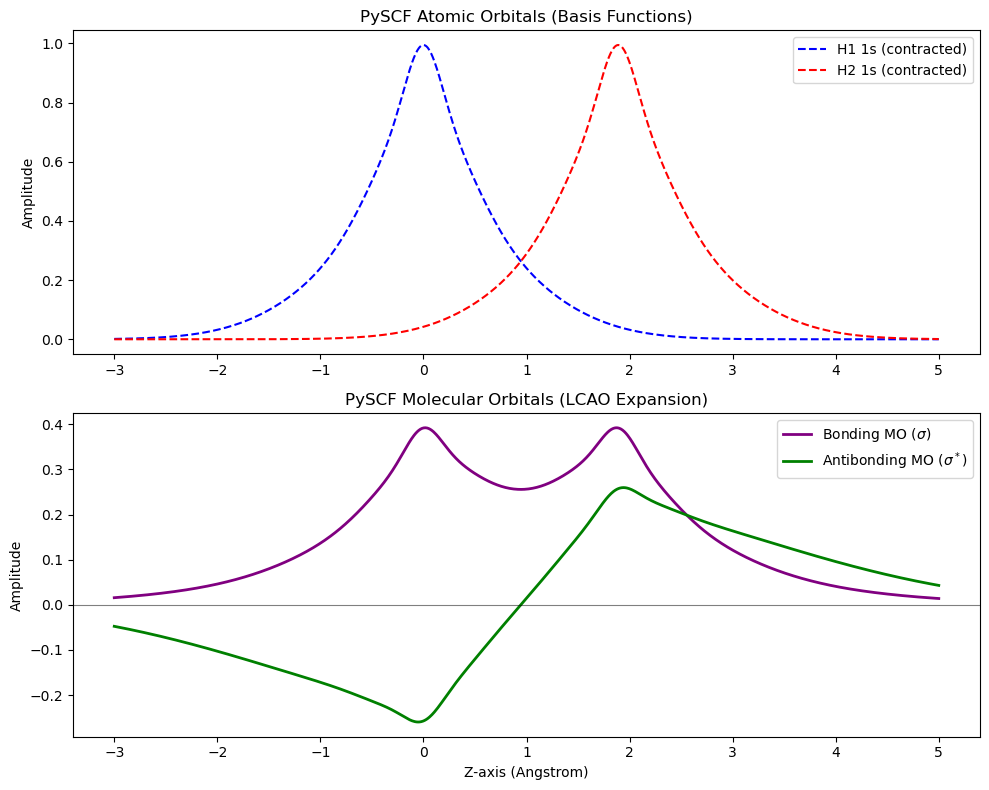

In [30]:
z = np.linspace(-3, 5, 1000)
points = np.zeros((1000, 3))
points[:, 2] = z

# Get the Atomic Orbitals
ao_values = mol.eval_gto("GTOval", points)

# Get the Molecular Orbitals
mo_values = np.dot(ao_values, mf.mo_coeff)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(z, ao_values[:, 0], label='H1 1s (contracted)', color='blue', linestyle='--')
ax1.plot(z, ao_values[:, 2], label='H2 1s (contracted)', color='red', linestyle='--')
ax1.set_title("PySCF Atomic Orbitals (Basis Functions)")
ax1.set_ylabel("Amplitude")
ax1.legend()

ax2.plot(z, mo_values[:, 0], label=r'Bonding MO ($\sigma$)', color='purple', linewidth=2)
ax2.plot(z, mo_values[:, 1], label=r'Antibonding MO ($\sigma^*$)', color='green', linewidth=2)
ax2.axhline(0, color='black', lw=0.8, alpha=0.5)
ax2.set_title("PySCF Molecular Orbitals (LCAO Expansion)")
ax2.set_xlabel("Z-axis (Angstrom)")
ax2.set_ylabel("Amplitude")
ax2.legend()

plt.tight_layout()
plt.show()

### Generalizing the HF Algorithm
We now wrap the iterative logic into a general-purpose function. This allows us to pass in arbitrary core Hamiltonians ($H_{core}$), overlap matrices ($S$), and Electron Repulsion Integrals (ERI) to solve any molecular system within the LCAO-MO framework.

In [31]:
def hartree_fock(S, H_core, eri, n_electrons, max_iter=50, tol=1e-6):
    """
    Basic restricted Hartree-Fock (RHF) implementation.

    Parameters:
        S: overlap matrix
        H_core: core Hamiltonian
        eri: two-electron integrals (4D tensor)
        n_electrons: total number of electrons
    """

    n_basis = S.shape[0]
    n_occ = n_electrons // 2

    # orthogonalization, get eigenvalues and eigenvectors of overlap matrix
    eigvals, eigvecs = eigh(S)
    S_inv_sqrt = eigvecs @ np.diag(eigvals**-0.5) @ eigvecs.T

    # set init guess
    P = np.zeros((n_basis, n_basis))  # density matrix

    E_old = 0

    # main fock guessing
    for iteration in range(max_iter):

        # build matrix
        J = np.einsum('pqrs,rs->pq', eri, P)
        K = np.einsum('prqs,rs->pq', eri, P)
        F = H_core + J - 0.5 * K

        # solve roothaan equations
        F_prime = S_inv_sqrt.T @ F @ S_inv_sqrt
        eps, C_prime = eigh(F_prime)
        C = S_inv_sqrt @ C_prime

        # build new density matrix
        C_occ = C[:, :n_occ]
        P_new = 2 * C_occ @ C_occ.T

        # compute energy
        E = 0.5 * np.sum(P_new * (H_core + F))

        # check convergence
        dE = abs(E - E_old)
        dP = np.linalg.norm(P_new - P)
        if dE < tol and dP < tol:
            break

        # continue if not converged yet (based on tolerance)
        P = P_new
        E_old = E

    return E, C, P

### Validation Function
The `compare` function extracts the one-electron and two-electron integrals from a PySCF molecule object and runs them through our custom SCF solver. It then displays the results side-by-side with PySCF's internal solver output for rigorous validation.

In [32]:
def compare(mol):
    """
    Compare custom Hartree-Fock implementation with PySCF results.
    """
    s = mol.intor('int1e_ovlp')
    t = mol.intor('int1e_kin')
    v = mol.intor('int1e_nuc')
    h_core = t + v
    eri = mol.intor('int2e')

    n_electrons = mol.nelectron
    e_nuc = mol.energy_nuc()

    # Assuming hartree_fock is defined elsewhere
    e_elec, c_coeff, p_mat = hartree_fock(
        S=s,
        H_core=h_core,
        eri=eri,
        n_electrons=n_electrons
    )

    e_total = e_elec + e_nuc

    mf = scf.RHF(mol)
    e_total_scf = mf.kernel()

    data = {
        'Implementation Results': [
            e_elec, e_nuc, e_total, c_coeff, p_mat
        ],
        'PySCF Results': [
            mf.energy_elec()[0],
            mol.energy_nuc(),
            e_total_scf,
            mf.mo_coeff,
            mf.make_rdm1()
        ]
    }

    index_labels = [
        'Electronic energy',
        'Nuclear Repulsion',
        'Total HF Energy',
        'MO Coefficients',
        'Density Matrix'
    ]

    return pd.DataFrame(data, index=index_labels)

**Data Table: Model Comparison**: This table compares our custom LCAO implementation against PySCF's standard Hartree-Fock results. By looking at the 'Total HF Energy' and 'MO Coefficients,' we can assess the accuracy of our simplified model in predicting molecular behavior.

In [33]:
# H2 molecule
mol_h2 = gto.M(
    atom='H 0 0 0; H 0 0 0.74',
    basis='sto-3g',
    unit='Angstrom'
)

# H2O
mol_h2o = gto.M(
    atom="""
    O  0.0000  0.0000  0.0000
    H  0.0000 -0.7570  0.5870
    H  0.0000  0.7570  0.5870
    """,
    basis="sto-3g",
    charge=0,
    spin=0,
    unit="Angstrom"
)

# O
mol_o = gto.M(
    atom="O 0 0 0",
    basis="sto-3g",
    spin=2
)

In [34]:
compare(mol_h2)

converged SCF energy = -1.11675930739642


,Implementation Results,PySCF Results
Electronic energy,-1.831864,-1.831864
Nuclear Repulsion,0.715104,0.715104
Total HF Energy,-1.116759,-1.116759
MO Coefficients,"[[-0.5488422750886978, -1.2124519201795327], [...","[[0.5488422750886981, -1.2124519201795327], [0..."
Density Matrix,"[[0.6024556858490756, 0.602455685849075], [0.6...","[[0.6024556858490763, 0.6024556858490752], [0...."


In [35]:
compare(mol_h2o)

converged SCF energy = -74.9630631297277


,Implementation Results,PySCF Results
Electronic energy,-84.151322,-84.151322
Nuclear Repulsion,9.188258,9.188258
Total HF Energy,-74.963063,-74.963063
MO Coefficients,"[[0.9941314610287781, 0.2328056692951853, 6.37...","[[0.9941314597636002, -0.23280562246818934, -1..."
Density Matrix,"[[2.106293909829601, -0.4462453991628637, 3.43...","[[2.106293834129031, -0.4462449618333454, -3.1..."


In [36]:
compare(mol_o)

converged SCF energy = -73.8041502332559


,Implementation Results,PySCF Results
Electronic energy,-73.661817,-73.80415
Nuclear Repulsion,0,0
Total HF Energy,-73.661817,-73.80415
MO Coefficients,"[[0.9950278051062853, -0.2631994835334744, 0.0...","[[0.9950278051062856, -0.26319948353347444, 0...."
Density Matrix,"[[2.1187086021338386, -0.5015066664444745, 0.0...","[[[1.05935430106692, -0.25075333322223753, 0.0..."


**Data Table: Model Comparison**: This table compares our custom LCAO implementation against PySCF's standard Hartree-Fock results. By looking at the 'Total HF Energy' and 'MO Coefficients,' we can assess the accuracy of our simplified model in predicting molecular behavior.

## Appendix: Unit Tests

In [37]:
# test solve_single_well
def square_well(x, V0):
        return np.where(np.abs(x) < 1, -V0, 0)

x = np.linspace(-5, 5, 1000)
V0 = 10

Es, psis = solve_single_well(x, square_well, V0)

# should have at least 1 bound state
assert len(Es) > 0

# energies should be bound: -V0 < E < 0
assert np.all(Es > -V0)
assert np.all(Es < 0)

# number of wavefunctions should match number of energies
assert psis.shape[0] == len(Es)

# each wavefunction should have same length as x
assert psis.shape[1] == len(x)

# wavefunctions should be normalized: integral |psi|^2 dx = 1
dx = x[1] - x[0]
norms = np.sum(np.abs(psis)**2, axis=1) * dx
assert np.allclose(norms, 1, atol=1e-5)

# energies should be sorted in increasing order
assert np.all(np.diff(Es) >= 0)

In [ ]:
# test Vp_f
def V(x, V0):
    return -V0 * (np.abs(x) < 1)

x = np.array([-3.5, -1.5, -0.5, 0.5, 1.5, 3.5])
b = 4
V0 = 10

result = Vp_f(x, b, V0)
expected = V((x + b/2) % b - b/2, V0) - V(x, V0)

assert np.allclose(result, expected)

In [ ]:
# test compute_integral
def V(x, V0):
    return np.zeros_like(x)

globals()["V"] = V

psis_f = [
    lambda x: 1.0,
    lambda x: x
]

Es = np.array([2.0, 3.0])

i1 = 0
i2 = 0
b = 1.0
V0 = 10.0
n = 0

result = compute_integral(psis_f, Es, i1, i2, b, V0, n)

# Since psi_0(x)=1, psi_0(x)=1, Es[0]=2,
# and Vp_f(x,b,V0)=0:
# integral from -20 to 20 of 2 dx = 80
expected = 80.0

assert np.isclose(result, expected, atol=1e-8)

In [ ]:
# test hartree_fock
mol = gto.M(
    atom="H 0 0 0; H 0 0 0.74",
    basis="sto-3g",
    unit="Angstrom"
)

S = mol.intor("int1e_ovlp")
H_core = mol.intor("int1e_kin") + mol.intor("int1e_nuc")
eri = mol.intor("int2e")

E_elec, C, P = hartree_fock(
    S=S,
    H_core=H_core,
    eri=eri,
    n_electrons=mol.nelectron,
    max_iter=100,
    tol=1e-10
)

E_total = E_elec + mol.energy_nuc()

# Reference PySCF RHF result
mf = scf.RHF(mol)
E_ref = mf.kernel()

assert np.isclose(E_total, E_ref, atol=1e-6)
assert C.shape == S.shape
assert P.shape == S.shape
assert np.allclose(P, P.T, atol=1e-10)

converged SCF energy = -1.11675930739642
